# GOOD DAY THRESHOLD TOURNAMENT

Проверяем 36 прозрачных threshold rules на готовом `good_day_features.csv`. Модели не переобучаются, EDA и feature engineering не повторяются. `actual_regret_5` используется только для evaluation.

> Важно: правила сравниваются и выбираются на одном out-of-time периоде. Поэтому winner является исследовательским кандидатом, а не независимо подтверждённым production-порогом. Для честной итоговой оценки нужен новый будущий период.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.good_day_thresholds import plot_rule, run_threshold_tournament

input_path = ROOT / 'reports/good_day_features.csv'
if not input_path.exists(): raise FileNotFoundError(input_path)
run = run_threshold_tournament(ROOT)
print('Input:', input_path.relative_to(ROOT))
print('Usable rows:', len(run['frame']))
print('Corridors:', ', '.join(sorted(run['frame'].corridor.unique())))
print('Rules:', len(run['grid']))
print('Forecasting retrained: NO')

Input: reports\good_day_features.csv
Usable rows: 1375
Corridors: AMD_RUB, KGS_RUB, KZT_RUB, TJS_RUB, UZS_RUB
Rules: 36
Forecasting retrained: NO


## 1. Ground truth и правила

Основной realized success: `actual_good_day = actual_regret_5 <= 0.005`. Rule generation использует только `favourability_percentile_90`, `past_advantage_5` и `predicted_regret_5`.

In [2]:
display(run['grid'])
display(run['signals'][['corridor','date','good_day_rule_a','good_day_rule_b','good_day_rule_c','actual_good_day']].head())

,rule,favourability_threshold,past_advantage_threshold,predicted_regret_threshold,thresholds,is_primary
0,GRID_F0.80_PANONE_PR0.002,0.80,NaN,0.002,fav>=0.800; past_advantage>=NONE; predicted_re...,False
1,GRID_F0.80_PANONE_PR0.005,0.80,NaN,0.005,fav>=0.800; past_advantage>=NONE; predicted_re...,False
2,RULE_A,0.80,NaN,0.010,fav>=0.800; past_advantage>=NONE; predicted_re...,True
3,GRID_F0.80_PA0.000_PR0.002,0.80,0.000,0.002,fav>=0.800; past_advantage>=0.000; predicted_r...,False
4,GRID_F0.80_PA0.000_PR0.005,0.80,0.000,0.005,fav>=0.800; past_advantage>=0.000; predicted_r...,False
5,GRID_F0.80_PA0.000_PR0.010,0.80,0.000,0.010,fav>=0.800; past_advantage>=0.000; predicted_r...,False
6,GRID_F0.80_PA0.002_PR0.002,0.80,0.002,0.002,fav>=0.800; past_advantage>=0.002; predicted_r...,False
7,GRID_F0.80_PA0.002_PR0.005,0.80,0.002,0.005,fav>=0.800; past_advantage>=0.002; predicted_r...,False
8,GRID_F0.80_PA0.002_PR0.010,0.80,0.002,0.010,fav>=0.800; past_advantage>=0.002; predicted_r...,False
9,GRID_F0.80_PA0.005_PR0.002,0.80,0.005,0.002,fav>=0.800; past_advantage>=0.005; predicted_r...,False


,corridor,date,good_day_rule_a,good_day_rule_b,good_day_rule_c,actual_good_day
0,AMD_RUB,2025-07-12,True,True,False,True
1,AMD_RUB,2025-07-15,True,False,False,False
2,AMD_RUB,2025-07-16,True,False,False,True
3,AMD_RUB,2025-07-17,True,False,False,True
4,AMD_RUB,2025-07-18,True,False,False,True


## 2. Tournament metrics

Random baseline использует 500 выборок с seed 42 и ровно тем же числом сигналов внутри каждой пары rule × corridor.

In [3]:
display(run['metrics'])
display(run['summary'].sort_values(['corridors_uplift_gt_1','macro_uplift'], ascending=False).head(15))

,rule,thresholds,favourability_threshold,past_advantage_threshold,predicted_regret_threshold,is_primary,corridor,actual_regret_tolerance,n_rows,n_signals,signal_frequency,hit_rate,random_hit_rate,uplift,mean_actual_regret_signal,median_actual_regret_signal,p90_actual_regret_signal
0,GRID_F0.80_PANONE_PR0.002,fav>=0.800; past_advantage>=NONE; predicted_re...,0.8,NaN,0.002,False,AMD_RUB,0.005,275,81,0.294545,0.543210,0.500346,1.085669,0.007892,0.003994,0.022155
1,GRID_F0.80_PANONE_PR0.002,fav>=0.800; past_advantage>=NONE; predicted_re...,0.8,NaN,0.002,False,KGS_RUB,0.005,275,90,0.327273,0.444444,0.498178,0.892140,0.009798,0.006103,0.023937
2,GRID_F0.80_PANONE_PR0.002,fav>=0.800; past_advantage>=NONE; predicted_re...,0.8,NaN,0.002,False,KZT_RUB,0.005,275,47,0.170909,0.425532,0.437489,0.972668,0.010068,0.007565,0.028036
3,GRID_F0.80_PANONE_PR0.002,fav>=0.800; past_advantage>=NONE; predicted_re...,0.8,NaN,0.002,False,TJS_RUB,0.005,275,99,0.360000,0.393939,0.489818,0.804256,0.010508,0.007370,0.026351
4,GRID_F0.80_PANONE_PR0.002,fav>=0.800; past_advantage>=NONE; predicted_re...,0.8,NaN,0.002,False,UZS_RUB,0.005,275,73,0.265455,0.465753,0.452082,1.030241,0.008831,0.005765,0.026284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,GRID_F0.90_PA0.005_PR0.010,fav>=0.900; past_advantage>=0.005; predicted_r...,0.9,0.005,0.010,False,AMD_RUB,0.005,275,12,0.043636,0.416667,0.495167,0.841468,0.011238,0.005795,0.029694
176,GRID_F0.90_PA0.005_PR0.010,fav>=0.900; past_advantage>=0.005; predicted_r...,0.9,0.005,0.010,False,KGS_RUB,0.005,275,17,0.061818,0.235294,0.499765,0.470810,0.012529,0.010076,0.027751
177,GRID_F0.90_PA0.005_PR0.010,fav>=0.900; past_advantage>=0.005; predicted_r...,0.9,0.005,0.010,False,KZT_RUB,0.005,275,8,0.029091,0.625000,0.451750,1.383509,0.005522,0.002007,0.013514
178,GRID_F0.90_PA0.005_PR0.010,fav>=0.900; past_advantage>=0.005; predicted_r...,0.9,0.005,0.010,False,TJS_RUB,0.005,275,14,0.050909,0.428571,0.479857,0.893123,0.010796,0.005986,0.028181


,rule,thresholds,actual_regret_tolerance,total_signals,overall_signal_frequency,macro_hit_rate,macro_uplift,median_uplift,corridors_uplift_gt_1,corridors_uplift_ge_1_3,mean_actual_regret_signal,status,is_primary
13,GRID_F0.85_PANONE_PR0.005,fav>=0.850; past_advantage>=NONE; predicted_re...,0.005,358,0.260364,0.470128,0.996803,1.033058,3,0,0.008999,OK,False
14,GRID_F0.85_PANONE_PR0.010,fav>=0.850; past_advantage>=NONE; predicted_re...,0.005,358,0.260364,0.470128,0.990280,1.043349,3,0,0.008999,OK,False
29,GRID_F0.90_PA0.000_PR0.010,fav>=0.900; past_advantage>=0.000; predicted_r...,0.005,132,0.096000,0.444443,0.941267,1.000770,3,0,0.010683,OK,False
27,GRID_F0.90_PA0.000_PR0.002,fav>=0.900; past_advantage>=0.000; predicted_r...,0.005,104,0.075636,0.429750,0.922794,1.014012,3,0,0.010668,OK,False
26,GRID_F0.90_PANONE_PR0.010,fav>=0.900; past_advantage>=NONE; predicted_re...,0.005,287,0.208727,0.466488,0.987158,0.953012,2,0,0.009178,OK,False
25,GRID_F0.90_PANONE_PR0.005,fav>=0.900; past_advantage>=NONE; predicted_re...,0.005,287,0.208727,0.466488,0.983725,0.953803,2,0,0.009178,OK,False
12,GRID_F0.85_PANONE_PR0.002,fav>=0.850; past_advantage>=NONE; predicted_re...,0.005,321,0.233455,0.460600,0.974814,0.954980,2,0,0.009013,OK,False
1,GRID_F0.80_PANONE_PR0.005,fav>=0.800; past_advantage>=NONE; predicted_re...,0.005,432,0.314182,0.457848,0.967891,0.994784,2,0,0.009478,TOO_FREQUENT,False
2,RULE_A,fav>=0.800; past_advantage>=NONE; predicted_re...,0.005,432,0.314182,0.457848,0.967450,0.992862,2,0,0.009478,TOO_FREQUENT,True
0,GRID_F0.80_PANONE_PR0.002,fav>=0.800; past_advantage>=NONE; predicted_re...,0.005,390,0.283636,0.454576,0.956995,0.972668,2,0,0.009434,OK,False


## 3. Primary rule table

In [4]:
display(run['primary'])

,rule,thresholds,actual_regret_tolerance,total_signals,signal_frequency,macro_hit_rate,macro_uplift,median_uplift,corridors_uplift_gt_1,corridors_uplift_ge_1_3,mean_actual_regret_signal,status,is_primary
0,RULE_A,fav>=0.800; past_advantage>=NONE; predicted_re...,0.005,432,0.314182,0.457848,0.967450,0.992862,2,0,0.009478,TOO_FREQUENT,True
1,RULE_B,fav>=0.850; past_advantage>=0.000; predicted_r...,0.005,148,0.107636,0.418418,0.895504,0.766479,1,1,0.010901,OK,True
2,RULE_C,fav>=0.900; past_advantage>=0.002; predicted_r...,0.005,109,0.079273,0.446803,0.954740,0.906501,1,1,0.010372,OK,True


## 4. RULE_A — BROAD

Красные точки — только сигналы правила; realized `actual_good_day` на графики не выводится.

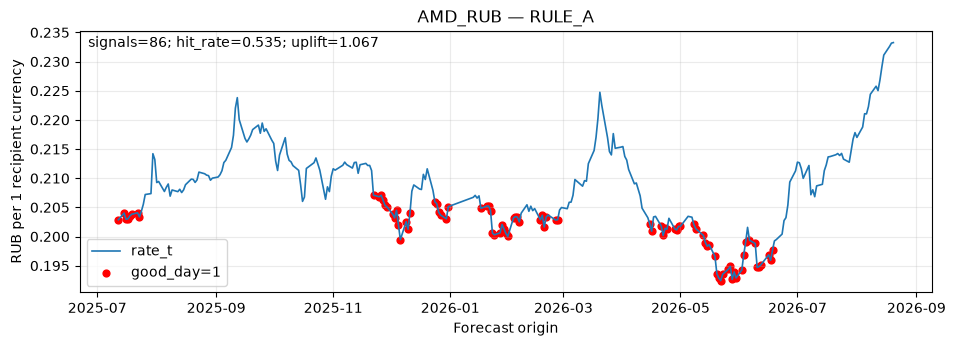

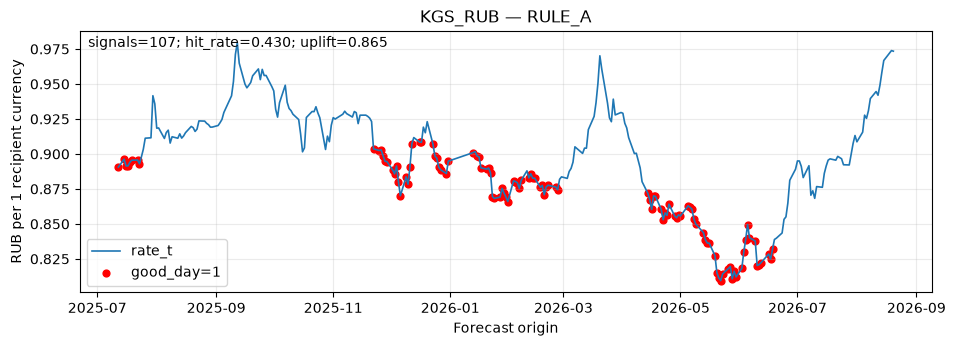

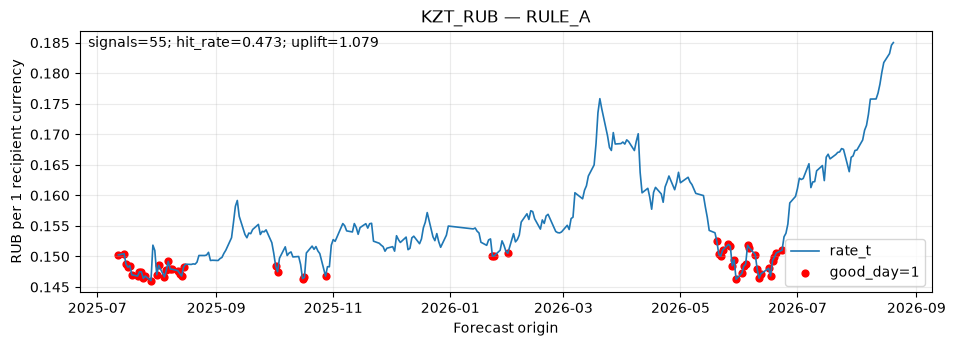

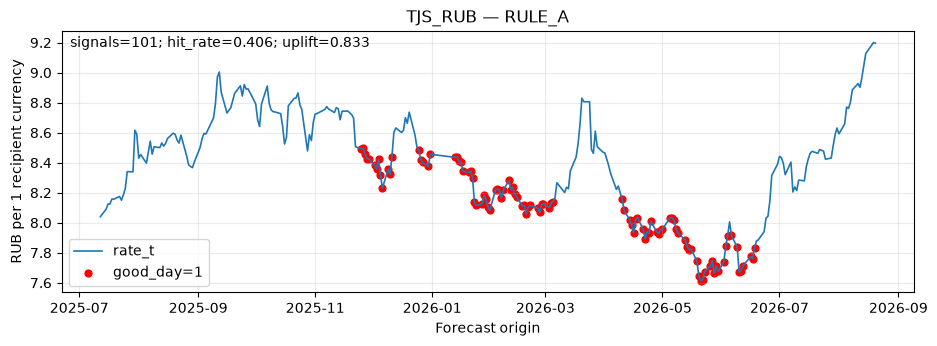

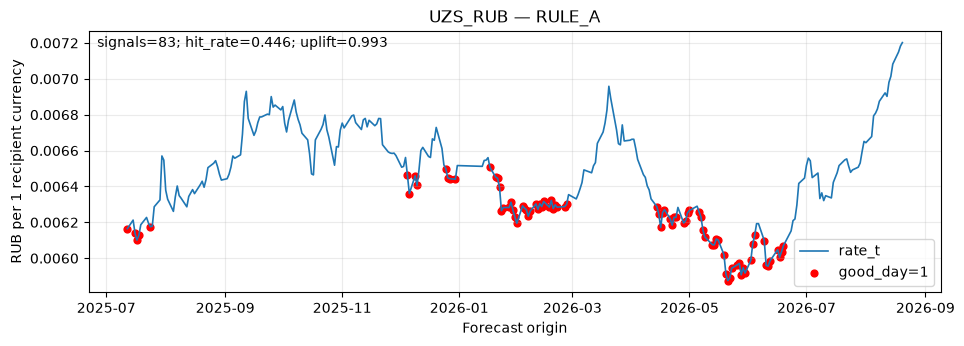

In [5]:
plot_rule(run['frame'], run['metrics'], run['grid'], 'RULE_A')

## 5. RULE_B — BALANCED

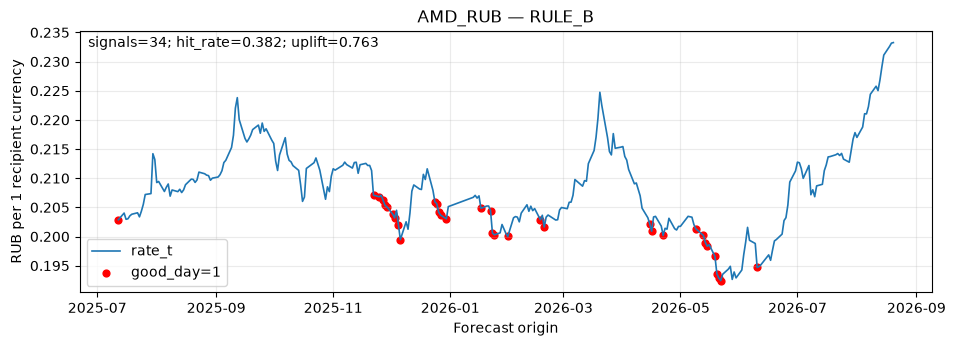

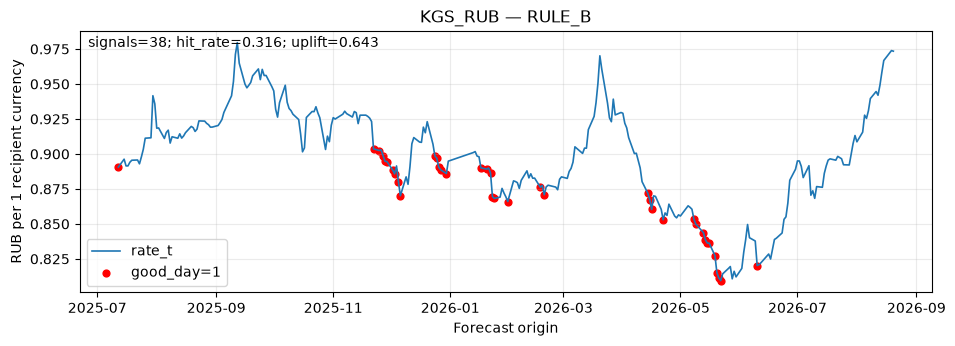

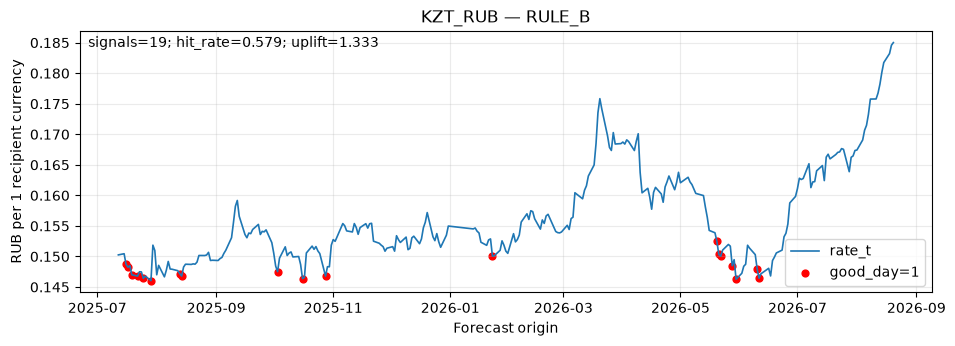

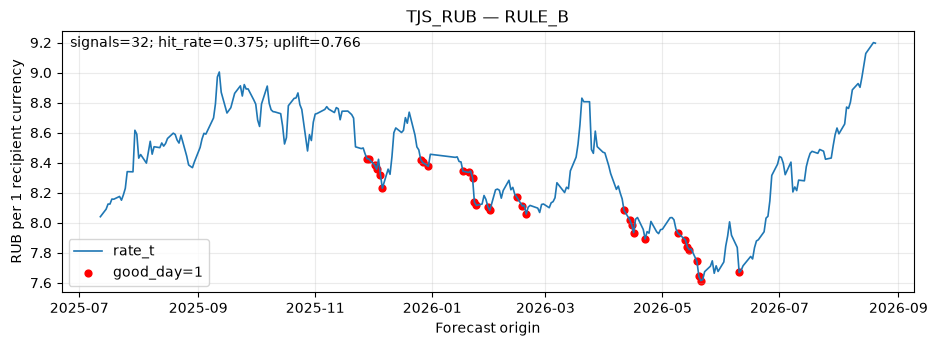

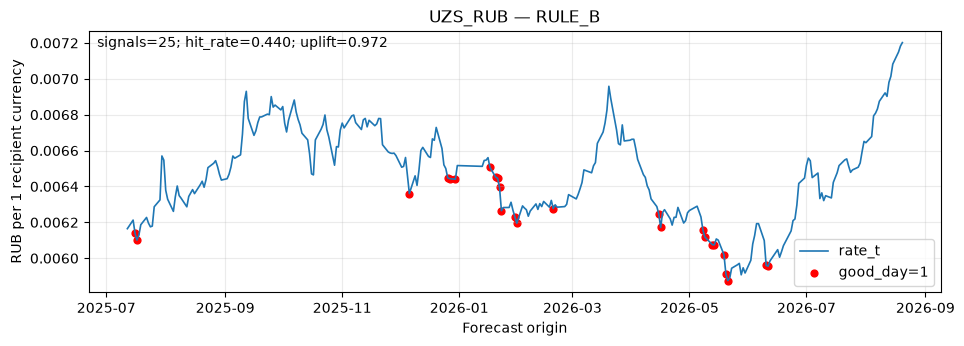

In [6]:
plot_rule(run['frame'], run['metrics'], run['grid'], 'RULE_B')

## 6. RULE_C — STRICT

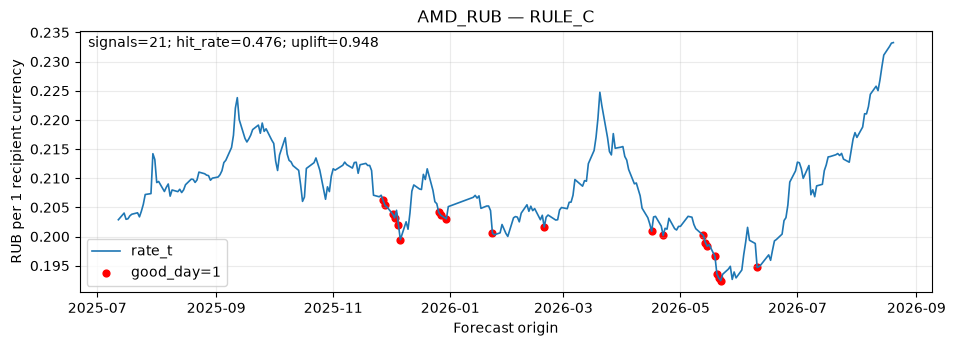

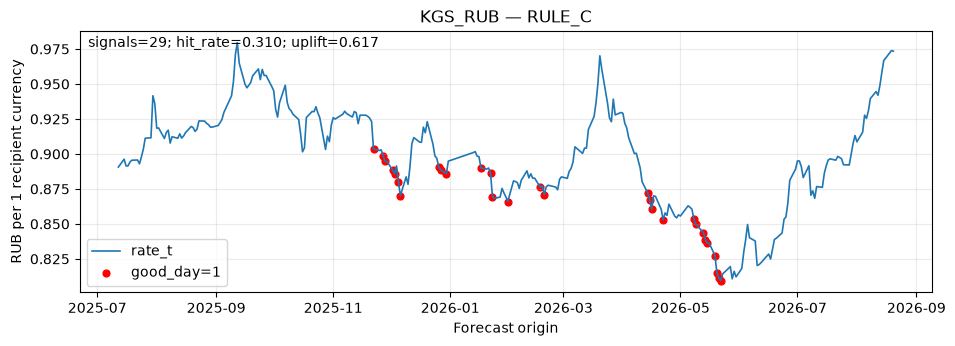

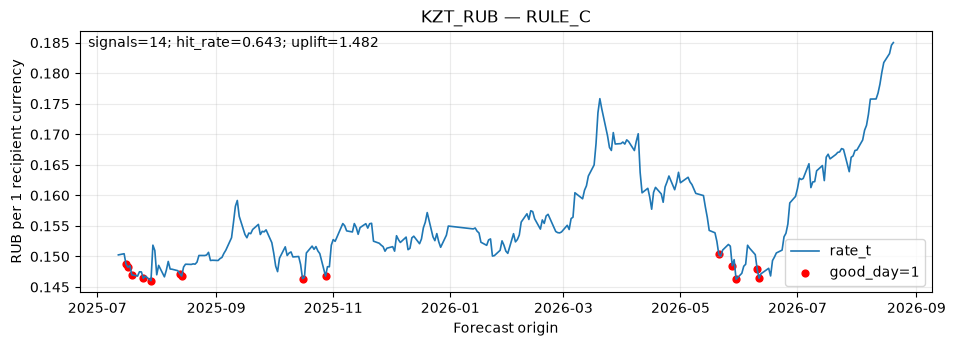

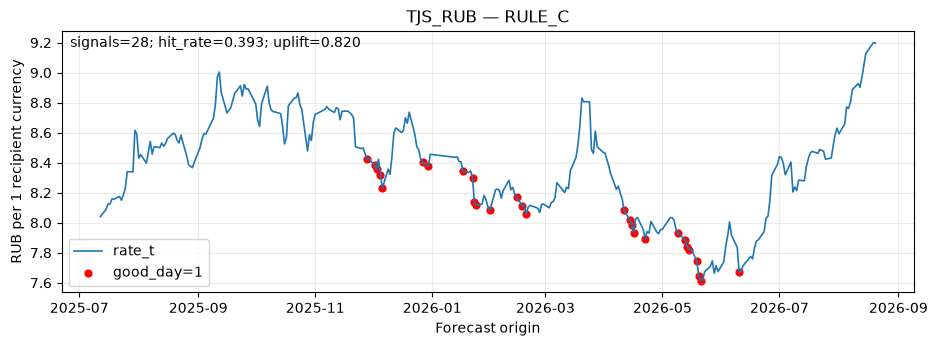

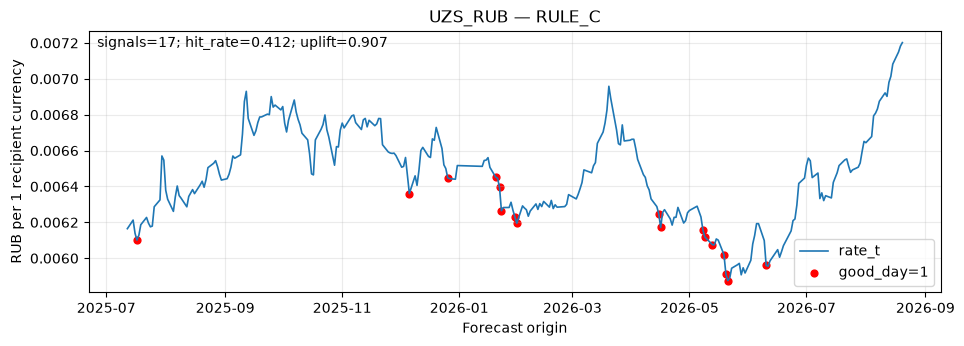

In [7]:
plot_rule(run['frame'], run['metrics'], run['grid'], 'RULE_C')

# WINNING RULE

In [8]:
print('WINNER:', run['winner'])
if run['winner'] != 'NO_STABLE_RULE':
    plot_rule(run['frame'], run['metrics'], run['grid'], run['winner'])
    display(run['false_positives'])
else:
    print('Устойчивого правила нет: повторные winner plots и таблица false positives не строятся.')

WINNER: NO_STABLE_RULE
Устойчивого правила нет: повторные winner plots и таблица false positives не строятся.


## 7. Sensitivity: tolerance 0.2%, 0.5%, 1.0%

Thresholds RULE_A/B/C не меняются; пересчитывается только evaluation ground truth.

In [9]:
display(run['sensitivity'])

,rule,thresholds,actual_regret_tolerance,total_signals,overall_signal_frequency,macro_hit_rate,macro_uplift,median_uplift,corridors_uplift_gt_1,corridors_uplift_ge_1_3,mean_actual_regret_signal,status,is_primary
0,RULE_A,fav>=0.800; past_advantage>=NONE; predicted_re...,0.002,432,0.314182,0.335004,0.889331,0.963684,1,0,0.009478,TOO_FREQUENT,True
3,RULE_A,fav>=0.800; past_advantage>=NONE; predicted_re...,0.005,432,0.314182,0.457848,0.967450,0.992862,2,0,0.009478,TOO_FREQUENT,True
6,RULE_A,fav>=0.800; past_advantage>=NONE; predicted_re...,0.010,432,0.314182,0.616863,1.033931,1.079512,3,0,0.009478,TOO_FREQUENT,True
1,RULE_B,fav>=0.850; past_advantage>=0.000; predicted_r...,0.002,148,0.107636,0.322152,0.863377,0.774833,2,0,0.010901,OK,True
4,RULE_B,fav>=0.850; past_advantage>=0.000; predicted_r...,0.005,148,0.107636,0.418418,0.895504,0.766479,1,1,0.010901,OK,True
7,RULE_B,fav>=0.850; past_advantage>=0.000; predicted_r...,0.010,148,0.107636,0.540685,0.904688,0.841121,2,0,0.010901,OK,True
2,RULE_C,fav>=0.900; past_advantage>=0.002; predicted_r...,0.002,109,0.079273,0.333010,0.887032,0.875219,2,0,0.010372,OK,True
5,RULE_C,fav>=0.900; past_advantage>=0.002; predicted_r...,0.005,109,0.079273,0.446803,0.954740,0.906501,1,1,0.010372,OK,True
8,RULE_C,fav>=0.900; past_advantage>=0.002; predicted_r...,0.010,109,0.079273,0.557302,0.933872,0.911162,2,0,0.010372,OK,True


## 8. Leakage check

In [10]:
display(run['leakage'])
leakage_status = 'PASS' if run['leakage'].passed.all() else 'FAIL'
print('GOOD DAY THRESHOLD LEAKAGE CHECK:', leakage_status)

,check,passed
0,signals use only the three approved causal fields,True
1,actual_regret_5 is evaluation-only,True
2,no actual future rate enters signal generation,True
3,identical rows compare all rules,True
4,random baseline uses exactly n_signals,True
5,one row per corridor+date,True


GOOD DAY THRESHOLD LEAKAGE CHECK: PASS


## 9. Final summary

In [11]:
for row in run['primary'].itertuples(index=False):
    print(f'{row.rule}: signals={row.total_signals}; hit_rate={row.macro_hit_rate:.3f}; uplift={row.macro_uplift:.3f}')
print('WINNER:', run['winner'])
if run['winner'] != 'NO_STABLE_RULE':
    winner = run['summary'].loc[run['summary'].rule.eq(run['winner'])].iloc[0]
    print('Winner macro uplift:', winner.macro_uplift)
    print('Winner signal frequency:', winner.overall_signal_frequency)
    print(f'Winner uplift > 1: {winner.corridors_uplift_gt_1}/5 corridors')
    print(f'Winner uplift >= 1.3: {winner.corridors_uplift_ge_1_3}/5 corridors')
else:
    print('Winner metrics: N/A — no rule passed the stability gate.')
print('Leakage:', leakage_status)
for name, path in run['paths'].items(): print(f'{name}: {path.relative_to(ROOT)}')

RULE_A: signals=432; hit_rate=0.458; uplift=0.967
RULE_B: signals=148; hit_rate=0.418; uplift=0.896
RULE_C: signals=109; hit_rate=0.447; uplift=0.955
WINNER: NO_STABLE_RULE
Winner metrics: N/A — no rule passed the stability gate.
Leakage: PASS
metrics: reports\good_day_threshold_tournament.csv
summary: reports\good_day_rule_summary.csv
report: reports\good_day_threshold_report.md
